# Exploración del mapeo de masks — valores en bruto, GG4 y subtipo **G4C**

Objetivos:
- Ver **qué valores de gris** toman las masks tras `cv2.imdecode` (antes de la LUT).
- Comparar distribuciones por **etiqueta Excel** (NC, G3, G4, G5).
- Centrarse en **GG4**: parches con `G4=1` y subtipo **G4C=1** (cribiforme) vs **G4C=0**.
- **Píxeles GG4 según la LUT actual**: entre parches G4C+ y G4C−, comparar intensidades en bruto only en pixeles que la `MASK_LUT` mapea a clase 2 (GG4).
- **Visualizer** pares imagen + mask (gris y coloreada por LUT/clase).
- **Inspección pixel a pixel** (`inspect_mask_pixelwise`): matrices 2D gris y clase (misma LUT + limpieza GG5 que `training_conch`), tabla y CSV; notas sobre **picos del histograma** y **ruido en bordes**.

Referencia de LUT by default (`build_mask_lut` / `DEFAULT_GG5_GRAY_MIN=170`): `[43:85)→GG3`, `[85:170)→GG4`, `[170:)→GG5`, rest NC (no `[160:170)` como GG5).

**Kernel:** entorno del proyecto (`prostata_env`) si falla `openpyxl`/`cv2`.

In [1]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.auto import tqdm

from sicap_mapping import CLASS_NAMES, MASK_LUT, build_mask_lut, clean_gg5_speckles
try:
    from sicap_mapping import DEFAULT_GG5_GRAY_MIN
except ImportError:
    DEFAULT_GG5_GRAY_MIN = 170



def find_project_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "partition").is_dir():
            return p
    raise FileNotFoundError("Not found partition/; define BASE manualmente.")


BASE = find_project_root()
IMAGES_DIR = BASE / "images"
MASKS_DIR = BASE / "masks"
PARTITION = BASE / "partition"
RNG = np.random.default_rng(42)

print("BASE:", BASE)

BASE: c:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2


c:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2\prostata_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def list_partition_excels() -> list[Path]:
    out: list[Path] = []
    for pat in (
        "Validation/*/Train.xlsx",
        "Validation/*/Test.xlsx",
        "Test/Train.xlsx",
        "Test/Test.xlsx",
    ):
        out.extend(sorted(PARTITION.glob(pat)))
    return out


def load_partition_unique() -> pd.DataFrame:
    """Una row por image_name (primera aparición en los Excel)."""
    parts = []
    for xp in list_partition_excels():
        df = pd.read_excel(xp)
        df["_from"] = str(xp.relative_to(BASE))
        parts.append(df)
    all_df = pd.concat(parts, ignore_index=True)
    all_df = all_df.drop_duplicates(subset=["image_name"], keep="first")
    return all_df


meta = load_partition_unique()
meta["main_label"] = meta[["NC", "G3", "G4", "G5"]].idxmax(axis=1)
meta["g4c"] = meta["G4C"].fillna(0).astype(int)
print("Parches únicos:", len(meta))
print(meta["main_label"].value_counts())
print("\nEntre rows con main_label==G4:")
g4 = meta["main_label"] == "G4"
print(meta.loc[g4, "g4c"].value_counts().sort_index())

Parches únicos: 12081
main_label
G4    4494
NC    4417
G3    2222
G5     948
Name: count, dtype: int64

Entre filas con main_label==G4:
g4c
0    3731
1     763
Name: count, dtype: int64


In [3]:
def read_mask_gray(name: str) -> np.ndarray | None:
    p = MASKS_DIR / name
    if not p.is_file():
        return None
    buf = np.fromfile(str(p), dtype=np.uint8)
    m = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    return m


def read_image_rgb(name: str) -> np.ndarray | None:
    p = IMAGES_DIR / name
    if not p.is_file():
        return None
    buf = np.fromfile(str(p), dtype=np.uint8)
    bgr = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def accumulate_hist_full_image(names: list[str], max_patches: int | None = None) -> np.ndarray:
    """Histograma global 0..255 de todos los pixeles de las masks listadas."""
    h = np.zeros(256, dtype=np.float64)
    use = names
    if max_patches is not None and len(names) > max_patches:
        use = list(RNG.choice(names, size=max_patches, replace=False))
    for name in tqdm(use, desc="Máscaras (hist. completo)"):
        m = read_mask_gray(name)
        if m is None:
            continue
        bc = np.bincount(m.ravel(), minlength=256)
        h += bc.astype(np.float64)
    return h


def accumulate_gg4_pixels_raw(
    names: list[str],
    *,
    gg5_gray_min: int | None = None,
    mask_clean_min_gg5_area: int | None = None,
) -> np.ndarray:
    """Solo pixeles donde la LUT (training) mapea a GG4 (2); concatena gris en bruto."""
    g5 = DEFAULT_GG5_GRAY_MIN if gg5_gray_min is None else int(gg5_gray_min)
    ca = 16 if mask_clean_min_gg5_area is None else int(mask_clean_min_gg5_area)
    lut = build_mask_lut(g5)
    chunks: list[np.ndarray] = []
    for name in tqdm(names, desc="Pixeles GG4 (LUT=2)"):
        m = read_mask_gray(name)
        if m is None:
            continue
        mapped = lut[m].astype(np.int64)
        if ca > 0:
            mapped = clean_gg5_speckles(mapped, min_area=ca)
        raw_gg4 = m[mapped == 2]
        if raw_gg4.size:
            chunks.append(raw_gg4.ravel())
    if not chunks:
        return np.array([], dtype=np.uint8)
    return np.concatenate(chunks)


# Cortes de gris (GG3, GG4, inicio GG5) alineados con sicap_mapping / training
LUT_BOUNDARIES = (43, 85, DEFAULT_GG5_GRAY_MIN)

## Por qué hay tantos picos en el histograma

- **Valores “canónicos” por clase:** al generar la mask se usan unos **pocos niveles de gris discretos** (p. ej. uno por Gleason / fondo). En el histograma aparecen como **picos agudos**, no como una campana continua.
- **JPEG:** al saver la mask como JPEG, el codec agrupa bloques 8×8 (DCT + cuantización). Eso **concentra** los valores en ciertos enteros y puede crear **valores intermedios** entre dos clases (sobre todo en **bordes** entre regiones o entre tejido y fondo).
- **Bordes y “ruido” de mapeo:** en los contornos, un pixel puede caer en un rango de gris que la LUT asigna a **otra clase** que el vecino interior (p. ej. ~82 vs ~88 cerca del corte 85). Eso explica parte del **mapeo erróneo en bordes** sin que el tejido cambie de grado real.

**Objetivo de las 4 clases:** la LUT only **parte el eje 0–255** en intervalos; afinar bordes puede imajar umbrales, **suavizado morfológico** post-LUT, o reglas only en pixeles de frontera — se puede explorar después de ver la tabla pixel a pixel.

---

## Inspección pixel a pixel para un `image_name`

La función siguiente carga la mask, aplica el mapeo actual y deja las matrices **2D** (`raw` y `clase`). Opcionalmente genera una tabla larga `(row, column, gris, clase)` y exporta CSV. **No imprime el array completo en consola** (sería enorme); usa `preview` o `save_csv`.

IMAGE_NAME_DEMO (por defecto, primero del meta): 16B0006668_Block_Region_3_10_15_xini_69838_yini_77884.jpg
image_name: 16B0006668_Block_Region_3_10_15_xini_69838_yini_77884.jpg
shape (H×W): 512 × 512 = 262,144 píxeles
[como training] gg5_gray_min=170, mask_clean_min_gg5_area=16

Valores de gris únicos en la máscara (toda la imagen):


,gray,count
0,0,246849
1,1,74
2,2,53
3,3,55
4,4,47
...,...,...
86,225,3
87,226,1
88,229,1
89,231,1



Clases tras LUT + limpieza (recuento de píxeles):


,class_id,class_name,count
0,0,NC,247509
1,2,GG4,1
2,3,GG5,14634



Primeras 12 filas (orden fila-major: col varía rápido):


,row,col,gray,class_id,class_name
0,0,0,0,0,NC
1,0,1,0,0,NC
2,0,2,0,0,NC
3,0,3,0,0,NC
4,0,4,0,0,NC
5,0,5,0,0,NC
6,0,6,0,0,NC
7,0,7,0,0,NC
8,0,8,0,0,NC
9,0,9,0,0,NC


... (262,144 filas en total; usar save_csv para volcar todo)


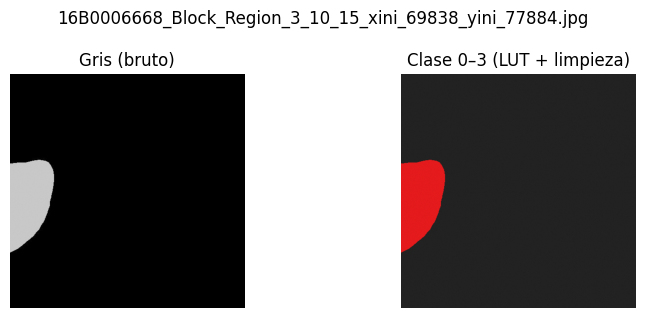

In [4]:
try:
    from IPython.display import display
except ImportError:
    display = print


def mask_pixelwise_table(raw: np.ndarray, class_map: np.ndarray) -> pd.DataFrame:
    """Una row por pixel: row, column, gris, class_id, class_name."""
    h, w = raw.shape
    ri, ci = np.indices((h, w))
    cid = class_map.ravel().astype(np.int64)
    return pd.DataFrame(
        {
            "row": ri.ravel(),
            "col": ci.ravel(),
            "gray": raw.ravel().astype(np.int64),
            "class_id": cid,
            "class_name": [CLASS_NAMES[c] for c in cid],
        }
    )


def inspect_mask_pixelwise(
    image_name: str,
    *,
    save_csv: str | Path | None = None,
    preview_rows: int = 12,
    plot: bool = True,
    gg5_gray_min: int | None = None,
    mask_clean_min_gg5_area: int | None = None,
):
    """
    Carga mask y aplica la same logic as training_conch (SICAPv2Dataset):
    build_mask_lut(gg5_gray_min) y optionalmente clean_gg5_speckles (GG5
    con componentes muy pequeños → GG4).

    Por defecto: gg5_gray_min = DEFAULT_GG5_GRAY_MIN (170);
    mask_clean_min_gg5_area = 16 (como DEFAULT_CONFIG en training_conch).
    Usa mask_clean_min_gg5_area=0 para disabler la limpieza.

    Devuelve:
    - raw_hw: (H,W) uint8, gris decodificado
    - class_hw: (H,W) int64, clases 0..3 tras LUT + limpieza
    """
    raw = read_mask_gray(image_name)
    if raw is None:
        print("No hay mask:", MASKS_DIR / image_name)
        return None

    g5 = DEFAULT_GG5_GRAY_MIN if gg5_gray_min is None else int(gg5_gray_min)
    clean_a = 16 if mask_clean_min_gg5_area is None else int(mask_clean_min_gg5_area)

    mask_lut = build_mask_lut(g5)
    class_hw = mask_lut[raw].astype(np.int64)
    if clean_a > 0:
        class_hw = clean_gg5_speckles(class_hw, min_area=clean_a)

    h, w = raw.shape
    print(f"image_name: {image_name}")
    print(f"shape (H×W): {h} × {w} = {h * w:,} pixeles")
    print(f"[como training] gg5_gray_min={g5}, mask_clean_min_gg5_area={clean_a}")

    # Valores únicos de gris y recuentos
    ug, cnt_g = np.unique(raw, return_counts=True)
    tab_gray = pd.DataFrame({"gray": ug.astype(np.int64), "count": cnt_g})
    print("\nValores de gris únicos en la mask (toda la imagen):")
    display(tab_gray)

    uc, cnt_c = np.unique(class_hw, return_counts=True)
    tab_cls = pd.DataFrame(
        {"class_id": uc.astype(np.int64), "class_name": [CLASS_NAMES[int(c)] for c in uc], "count": cnt_c}
    )
    print("\nClases tras LUT + limpieza (recuento de pixeles):")
    display(tab_cls)

    tbl = mask_pixelwise_table(raw, class_hw)
    if preview_rows and len(tbl) > 0:
        print(f"\nPrimeras {preview_rows} rows (orden row-major: col varía rápido):")
        display(tbl.head(preview_rows))
        if len(tbl) > preview_rows:
            print(f"... ({len(tbl):,} rows en total; usar save_csv para volcar todo)")

    if save_csv is not None:
        out = Path(save_csv)
        tbl.to_csv(out, index=False)
        print(f"\nCSV savedo: {out.resolve()} ({len(tbl):,} rows)")

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
        axes[0].imshow(raw, cmap="gray", vmin=0, vmax=255)
        axes[0].set_title("Gris (bruto)")
        axes[1].imshow(
            class_hw,
            cmap=ListedColormap(["#222", "#4daf4a", "#377eb8", "#e41a1c"]),
            vmin=0,
            vmax=3,
        )
        axes[1].set_title("Clase 0–3 (LUT + limpieza)")
        for ax in axes:
            ax.axis("off")
        plt.suptitle(image_name[:70] + ("…" if len(image_name) > 70 else ""))
        plt.tight_layout()
        plt.show()

    return {"raw_hw": raw, "class_hw": class_hw, "table": tbl}


# Ejemplo: cambia IMAGE_NAME_DEMO por cualquier `image_name` de `meta` o pega el string completo
IMAGE_NAME_DEMO = '16B0006668_Block_Region_3_10_15_xini_69838_yini_77884.jpg'
print("IMAGE_NAME_DEMO (by default, primero del meta):", IMAGE_NAME_DEMO)
result = inspect_mask_pixelwise(IMAGE_NAME_DEMO, preview_rows=12)
# Volcar todos los pixeles a CSV (muchas rows):
# result = inspect_mask_pixelwise(IMAGE_NAME_DEMO, save_csv=BASE / "tmp_mask_pixels.csv", preview_rows=0, plot=True)


## Ruido y coherencia del mapeo (LUT + limpieza)

Mismo pipeline que `training_conch`: `build_mask_lut(DEFAULT_GG5_GRAY_MIN)` y `clean_gg5_speckles` (área mínima 16).

- **Por mask**: porcentaje de pixeles NC, GG3, GG4, GG5; se marcan masks donde alguna clase aparece con fracción muy pequeña (posible **ruido JPEG / bordes**), sobre todo GG5 residual.
- **Histogramas**: distribución del % de la clase más débil presente; distribución del % GG5 only donde hay GG5.
- **Excel vs mask**: tabla cruzada `main_label` (parche) versus **mayoría** en la mask (no deben coincidir siempre: el tumor puede ocupar poca superficie del parche).

Los histogramas de más abajo (por grupo Excel) usan los mismos cortes en gris que `LUT_BOUNDARIES` (ahora con umbral GG5 = `DEFAULT_GG5_GRAY_MIN`, no 160).


Fracciones por mascara: 100%|██████████| 12081/12081 [01:19<00:00, 151.22it/s]


Mascaras analizadas: 12081

--- Clases con 0 < pct < 0.1% del parche ---
  NC: 9 mascaras
  GG3: 2,503 mascaras
  GG4: 1,390 mascaras
  GG5: 340 mascaras


,clase,n_mascaras_sospechosas
0,NC,9
1,GG3,2503
2,GG4,1390
3,GG5,340



12 mascaras con menor 'min_pct_among_present' (minoritaria muy debil):


,image_name,main_label,majority_name,min_pct_among_present,pct_NC,pct_GG3,pct_GG4,pct_GG5
102,16B0006668_Block_Region_3_10_15_xini_69838_yin...,G5,NC,0.000381,94.417191,0.000000,0.000381,5.582428
148,16B0006668_Block_Region_3_21_8_xini_62670_yini...,G5,GG5,0.000381,4.854965,0.000000,0.000381,95.144653
150,16B0006668_Block_Region_3_22_6_xini_60622_yini...,G5,GG5,0.000381,47.823334,0.000000,0.000381,52.176285
151,16B0006668_Block_Region_3_22_7_xini_61646_yini...,G5,GG5,0.000381,10.098648,0.000000,0.000381,89.900970
152,16B0006668_Block_Region_3_22_8_xini_62670_yini...,G5,GG5,0.000381,0.544739,0.000000,0.000381,99.454880
154,16B0006668_Block_Region_3_23_5_xini_59598_yini...,G5,NC,0.000381,57.440186,0.000000,0.000381,42.559433
160,16B0006668_Block_Region_3_24_7_xini_61646_yini...,G5,GG5,0.000381,3.326035,0.000000,0.000381,96.673584
165,16B0006668_Block_Region_3_25_6_xini_60622_yini...,G5,GG5,0.000381,3.111649,0.000000,0.000381,96.887970
166,16B0006668_Block_Region_3_25_7_xini_61646_yini...,G5,GG5,0.000381,27.750778,0.000000,0.000381,72.248840
172,16B0006668_Block_Region_3_26_5_xini_59598_yini...,G5,GG5,0.000381,16.798782,0.000381,0.003433,83.197403


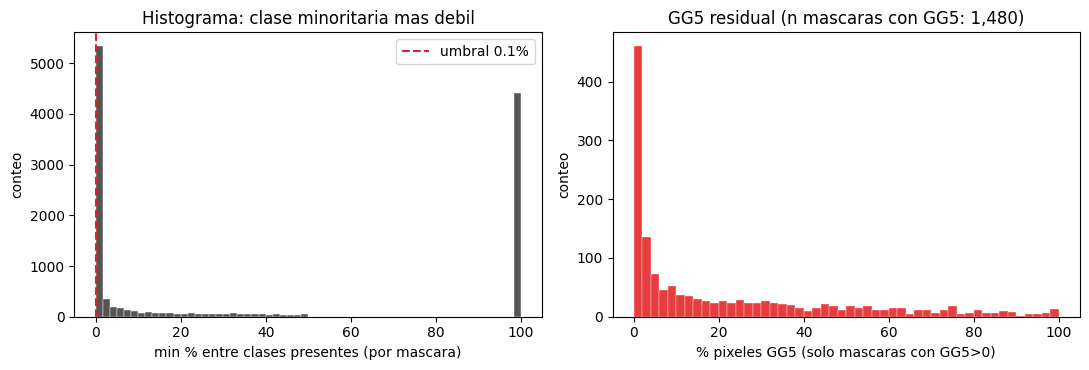


Crosstab: main_label (Excel) vs clase mayoritaria (mascara mapeada)


majority_name,GG3,GG4,GG5,NC,All
main_label,,,,,
G3,520,0,0,1702,2222
G4,0,1266,0,3228,4494
G5,0,0,253,695,948
NC,0,0,0,4417,4417
All,520,1266,253,10042,12081


Coincidencia exacta Excel vs mayoria mascara: 53.44% (interpretar con cuidado).
  Total pixeles NC: 2,464,119,583 (77.8071% del total)
  Total pixeles GG3: 191,606,973 (6.0502% del total)
  Total pixeles GG4: 427,535,038 (13.4998% del total)
  Total pixeles GG5: 83,700,070 (2.6429% del total)


In [5]:
# Mismo pipeline que training_conch
GG5_M = DEFAULT_GG5_GRAY_MIN
CLEAN_A = 16
# Umbral: clase "presente" pero con poco peso en el parche (posible ruido / bordes)
NOISE_PCT_THRESHOLD = 0.1  # % del parche; sube a 0.5 si casi no hay casos


def map_mask_training(raw: np.ndarray) -> np.ndarray:
    lut = build_mask_lut(GG5_M)
    m = lut[raw].astype(np.int64)
    if CLEAN_A > 0:
        m = clean_gg5_speckles(m, min_area=CLEAN_A)
    return m


def per_mask_class_stats(names: list[str]) -> pd.DataFrame:
    """Una row por mask: % y recuentes por clase tras mapeo."""
    rows: list[dict] = []
    for name in tqdm(names, desc="Fracciones por mascara"):
        raw = read_mask_gray(name)
        if raw is None:
            continue
        m = map_mask_training(raw)
        npx = m.size
        bc = np.bincount(m.ravel().astype(np.int64), minlength=4)
        pcts = 100.0 * bc / max(npx, 1)
        present = [c for c in range(4) if bc[c] > 0]
        min_pct = min(float(100.0 * bc[c] / npx) for c in present) if present else 0.0
        rows.append(
            {
                "image_name": name,
                "n_pixels": int(npx),
                "majority_class": int(np.argmax(bc)),
                **{f"pct_{CLASS_NAMES[c]}": float(pcts[c]) for c in range(4)},
                **{f"n_{CLASS_NAMES[c]}": int(bc[c]) for c in range(4)},
                "min_pct_among_present": min_pct,
            }
        )
    return pd.DataFrame(rows)


mask_per_class = per_mask_class_stats(meta["image_name"].tolist())
print("Mascaras analizadas:", len(mask_per_class))

LABEL_TO_IDX = {"NC": 0, "G3": 1, "G4": 2, "G5": 3}
ms = mask_per_class.merge(meta[["image_name", "main_label", "g4c"]], on="image_name", how="left")
ms["excel_idx"] = ms["main_label"].map(LABEL_TO_IDX)
ms["majority_name"] = ms["majority_class"].map(lambda i: CLASS_NAMES[int(i)])

# --- 1) Máscaras con alguna clase en porcentaje muy bajo (posible ruido)
print(f"\n--- Clases con 0 < pct < {NOISE_PCT_THRESHOLD}% del parche ---")
for c in range(4):
    cn = CLASS_NAMES[c]
    col_pct = f"pct_{cn}"
    col_n = f"n_{cn}"
    hit = ms[(ms[col_n] > 0) & (ms[col_pct] < NOISE_PCT_THRESHOLD)]
    print(f"  {cn}: {len(hit):,} mascaras")
display(
    pd.DataFrame(
        {
            "clase": [CLASS_NAMES[c] for c in range(4)],
            "n_mascaras_sospechosas": [
                int(((ms[f"n_{CLASS_NAMES[c]}"] > 0) & (ms[f"pct_{CLASS_NAMES[c]}"] < NOISE_PCT_THRESHOLD)).sum())
                for c in range(4)
            ],
        }
    )
)

# Ejemplos: menor % mínimo entre clases presentes (parches casi monocromos en clase minoritaria)
show = ms.nsmallest(12, "min_pct_among_present")[
    ["image_name", "main_label", "majority_name", "min_pct_among_present"]
    + [f"pct_{CLASS_NAMES[c]}" for c in range(4)]
]
print("\n12 mascaras con menor 'min_pct_among_present' (minoritaria muy debil):")
display(show)

# --- 2) Distribución de min_pct_among_present (hay muchos parches casi puros en una clase)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax0, ax1 = axes
ax0.hist(ms["min_pct_among_present"], bins=60, color="#555", edgecolor="white", linewidth=0.3)
ax0.set_xlabel("min % entre clases presentes (por mascara)")
ax0.set_ylabel("conteo")
ax0.set_title("Histograma: clase minoritaria mas debil")
ax0.axvline(NOISE_PCT_THRESHOLD, color="C3", ls="--", label=f"umbral {NOISE_PCT_THRESHOLD}%")
ax0.legend()

g5p = ms[ms["n_GG5"] > 0]
if len(g5p):
    ax1.hist(g5p["pct_GG5"], bins=50, color="#e41a1c", alpha=0.85, edgecolor="white", linewidth=0.3)
    ax1.set_xlabel("% pixeles GG5 (only mascaras con GG5>0)")
    ax1.set_ylabel("conteo")
    ax1.set_title(f"GG5 residual (n mascaras con GG5: {len(g5p):,})")
else:
    ax1.text(0.5, 0.5, "Ninguna mascara con GG5", ha="center", va="center")
plt.tight_layout()
plt.show()

# --- 3) Excel vs mayoría en mask
ct = pd.crosstab(ms["main_label"], ms["majority_name"], margins=True)
print("\nCrosstab: main_label (Excel) vs clase mayoritaria (mascara mapeada)")
display(ct)
agree = (ms["excel_idx"] == ms["majority_class"]).mean()
print(f"Coincidencia exacta Excel vs mayoria mascara: {100*agree:.2f}% (interpretar con cuidado).")

# --- 4) Resumen numérico global (debe coincidir con analyze_masks.py en modo particion)
tot = ms["n_pixels"].sum()
for c in range(4):
    cn = CLASS_NAMES[c]
    s = ms[f"n_{cn}"].sum()
    print(f"  Total pixeles {cn}: {s:,} ({100*s/tot:.4f}% del total)")


### Interpretación (ruido vs. mapeo) y soluciones

**Qué dicen tus números**

- `min_pct_among_present` ≈ **0,000381%** en 512×512 (262 144 px) es **~1 pixel**. Las rows "minoritaria muy débil" suelen ser **un único pixel** distinto (borde, JPEG), no un fallo global de la LUT.
- **Miles de masks con GG3/GG4 en (0, 0,1%)**: suelen ser **fronteras** o cuantización; el histograma por Excel muestra **solapamiento** — la etiqueta es de **parche**, no pureza pixel a pixel.
- **GG5 residual** cerca de 0%: tras `clean_gg5_speckles` puede quedar cola fina; prueba subir `gg5_gray_min` o `mask_clean_min_gg5_area`.

**Qué hacer (orden recomendado)**

1. **Criterio doble** para "ruido": bajo **%** **y** bajo **n** de pixeles (p. ej. `n < 16`, como la limpieza GG5).
2. **Celda siguiente**: barrido de umbrales (% y doble condición).
3. **Entrenamiento**: `gg5_gray_min` 175–180 o área mínima GG5 mayor (32, 64).
4. **Opcional**: limpieza por componentes para **GG3/GG4** (análogo a GG5) o morfología por clase.

**No** esperes alta coincidencia Excel vs mayoría en mask (tumor focal vs estroma).


In [6]:
# Requiere la celda anterior (`ms` definido)

ex = int(ms["n_pixels"].iloc[0]) if len(ms) else 262144
print("Pixeles por parche (referencia):", ex)
print("  -> 1 pixel =", f"{100.0/ex:.6f}", "% del parche")
print("  -> 0.1% del parche ~", max(1, int(round(0.001 * ex))), "pixeles\n")

rows_pct = []
for thr in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]:
    row = {"pct_thr": thr}
    for c in range(4):
        cn = CLASS_NAMES[c]
        n = int(((ms[f"n_{cn}"] > 0) & (ms[f"pct_{cn}"] < thr)).sum())
        row[cn] = n
    rows_pct.append(row)
tab_pct = pd.DataFrame(rows_pct)
print("Mascaras con clase presente y pct < umbral (only relativo):")
display(tab_pct)

rows_dual = []
for thr in [0.1, 0.5, 1.0]:
    for nmax in [4, 8, 16, 32, 64]:
        row = {"pct_lt": thr, "n_lt": nmax}
        for c in range(4):
            cn = CLASS_NAMES[c]
            n = int(
                (
                    (ms[f"n_{cn}"] > 0)
                    & (ms[f"pct_{cn}"] < thr)
                    & (ms[f"n_{cn}"] < nmax)
                ).sum()
            )
            row[cn] = n
        rows_dual.append(row)
tab_dual = pd.DataFrame(rows_dual)
print("\nMascaras con 0 < pct < umbral% Y n_clase < n_max pixeles:")
display(tab_dual.sort_values(["pct_lt", "n_lt"]))

print("\nMascaras con 0 < n_clase < 16 (sin condicion de %):")
for c in range(4):
    cn = CLASS_NAMES[c]
    k = int(((ms[f"n_{cn}"] > 0) & (ms[f"n_{cn}"] < 16)).sum())
    print(f"  {cn}: {k:,}")


Pixeles por parche (referencia): 262144
  -> 1 pixel = 0.000381 % del parche
  -> 0.1% del parche ~ 262 pixeles

Mascaras con clase presente y pct < umbral (solo relativo):


,pct_thr,NC,GG3,GG4,GG5
0,0.001,1,235,312,0
1,0.005,1,265,1140,0
2,0.010,1,305,1290,28
3,0.050,5,1516,1353,257
4,0.100,9,2503,1390,340
5,0.500,34,3120,1485,384
6,1.000,52,3298,1552,407



Mascaras con 0 < pct < umbral% Y n_clase < n_max pixeles:


,pct_lt,n_lt,NC,GG3,GG4,GG5
0,0.1,4,1,242,439,0
1,0.1,8,1,253,871,0
2,0.1,16,1,270,1178,0
3,0.1,32,1,334,1297,32
4,0.1,64,1,655,1316,127
5,0.5,4,1,242,439,0
6,0.5,8,1,253,871,0
7,0.5,16,1,270,1178,0
8,0.5,32,1,334,1297,32
9,0.5,64,1,655,1316,127



Mascaras con 0 < n_clase < 16 (sin condicion de %):
  NC: 1
  GG3: 270
  GG4: 1,178
  GG5: 0


## Histogramas de **toda** la mask (gris en bruto)

Por grupo según `main_label` en Excel. Si hay muchos parches, puedes bajar `MAX_PATCHES_PER_GROUP`.

Máscaras (hist. completo): 100%|██████████| 948/948 [00:00<00:00, 1072.25it/s]


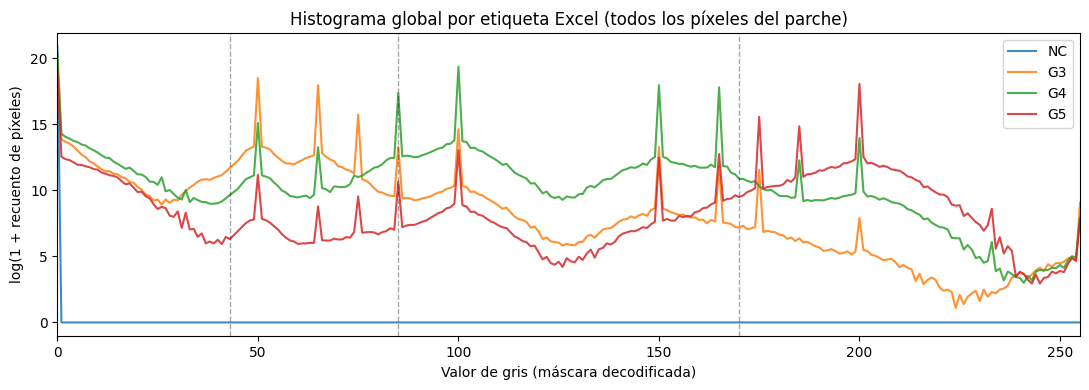

In [7]:
MAX_PATCHES_PER_GROUP: int | None = None  # ej. 800 para prueba rápida


def hist_by_names(names: list[str]) -> np.ndarray:
    return accumulate_hist_full_image(names, max_patches=MAX_PATCHES_PER_GROUP)


groups = {
    "NC": meta.loc[meta["main_label"] == "NC", "image_name"].tolist(),
    "G3": meta.loc[meta["main_label"] == "G3", "image_name"].tolist(),
    "G4": meta.loc[meta["main_label"] == "G4", "image_name"].tolist(),
    "G5": meta.loc[meta["main_label"] == "G5", "image_name"].tolist(),
}
hists_raw: dict[str, np.ndarray] = {}
for lab, names in groups.items():
    if not names:
        continue
    hists_raw[lab] = hist_by_names(names)

x = np.arange(256)
fig, ax = plt.subplots(figsize=(11, 4))
for lab, h in hists_raw.items():
    ax.plot(x, np.log1p(h), label=lab, alpha=0.85)
for b in LUT_BOUNDARIES:
    ax.axvline(b, color="k", linestyle="--", alpha=0.35, linewidth=1)
ax.set_xlabel("Valor de gris (mask decodificada)")
ax.set_ylabel("log(1 + recuento de pixeles)")
ax.set_title("Histograma global por etiqueta Excel (todos los pixeles del parche)")
ax.legend()
ax.set_xlim(0, 255)
plt.tight_layout()
plt.show()

## GG4 en Excel: **G4C=1** vs **G4C=0** (histograma de parche completo)

Misma métrica que arriba: todos los pixeles de cada mask, agrupados por subtipo.

Parches G4 con G4C=1: 763 | G4 con G4C=0: 3731


Máscaras (hist. completo): 100%|██████████| 3731/3731 [00:03<00:00, 1075.73it/s]


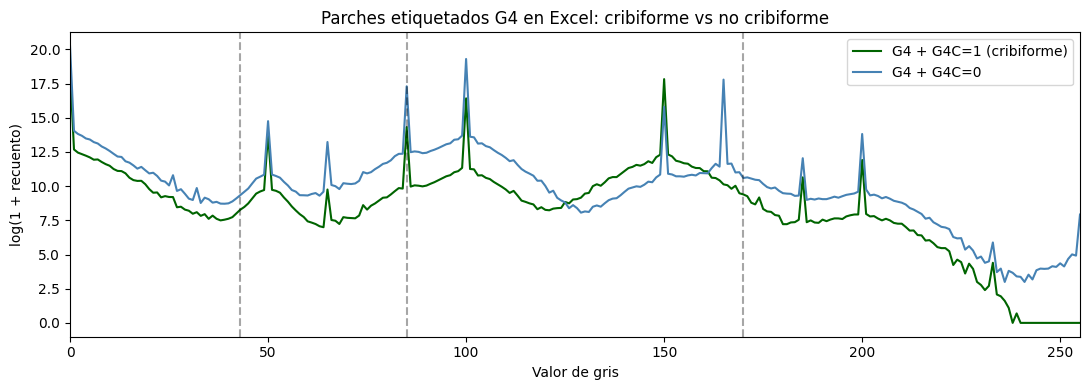

In [8]:
g4 = meta["main_label"] == "G4"
names_g4_crib = meta.loc[g4 & (meta["g4c"] == 1), "image_name"].tolist()
names_g4_plain = meta.loc[g4 & (meta["g4c"] == 0), "image_name"].tolist()
print(f"Parches G4 con G4C=1: {len(names_g4_crib)} | G4 con G4C=0: {len(names_g4_plain)}")

h_crib = hist_by_names(names_g4_crib) if names_g4_crib else np.zeros(256)
h_plain = hist_by_names(names_g4_plain) if names_g4_plain else np.zeros(256)

x = np.arange(256)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, np.log1p(h_crib), label="G4 + G4C=1 (cribiforme)", color="darkgreen")
ax.plot(x, np.log1p(h_plain), label="G4 + G4C=0", color="steelblue")
for b in LUT_BOUNDARIES:
    ax.axvline(b, color="k", linestyle="--", alpha=0.35)
ax.set_xlabel("Valor de gris")
ax.set_ylabel("log(1 + recuento)")
ax.set_title("Parches etiquetados G4 en Excel: cribiforme vs no cribiforme")
ax.legend()
ax.set_xlim(0, 255)
plt.tight_layout()
plt.show()

## Solo pixeles que la LUT actual clasifica como **GG4** (clase 2)

Aquí se ignoran pixeles NC/G3/G5 dentro del parche: only intensidades en bruto de regiones que **ya** caen en `[85, DEFAULT_GG5_GRAY_MIN)` (p. ej. `[85,170)` con el mapeo by default) con la LUT vigente. Sirve para ver si G4C+ y G4C− se separan en el espacio de gris **dentro** de GG4.

Pixeles GG4 (LUT=2): 100%|██████████| 3731/3731 [00:12<00:00, 305.16it/s]


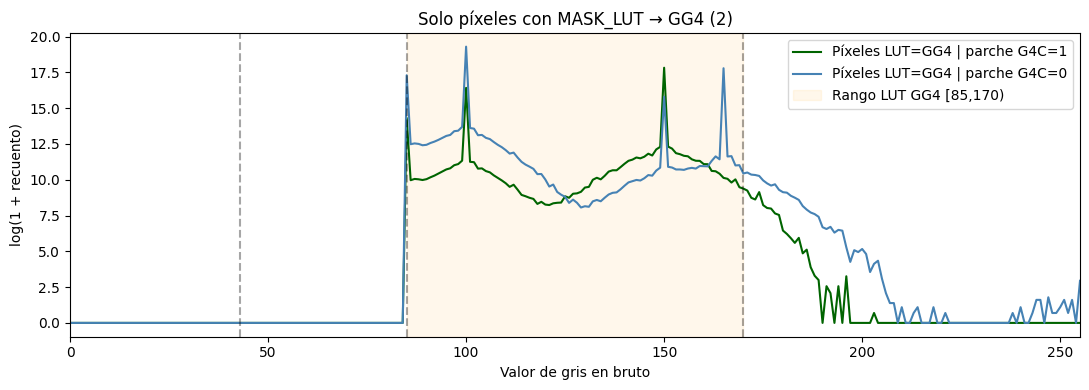

Media gris (solo píxeles LUT=GG4) | G4C=1: 138.78 | G4C=0: 109.92


In [9]:
pix_g4_crib = accumulate_gg4_pixels_raw(names_g4_crib)
pix_g4_plain = accumulate_gg4_pixels_raw(names_g4_plain)


def hist_from_pixels(pixels: np.ndarray) -> np.ndarray:
    if pixels.size == 0:
        return np.zeros(256)
    return np.bincount(pixels.astype(np.int64), minlength=256).astype(np.float64)


hc = hist_from_pixels(pix_g4_crib)
hp = hist_from_pixels(pix_g4_plain)

x = np.arange(256)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, np.log1p(hc), label="Píxeles LUT=GG4 | parche G4C=1", color="darkgreen")
ax.plot(x, np.log1p(hp), label="Píxeles LUT=GG4 | parche G4C=0", color="steelblue")
for b in LUT_BOUNDARIES:
    ax.axvline(b, color="k", linestyle="--", alpha=0.35)
ax.axvspan(85, DEFAULT_GG5_GRAY_MIN, alpha=0.08, color="orange", label=f"Rango LUT GG4 [85,{DEFAULT_GG5_GRAY_MIN})")
ax.set_xlim(0, 255)
ax.set_xlabel("Valor de gris en bruto")
ax.set_ylabel("log(1 + recuento)")
ax.set_title("Solo pixeles con MASK_LUT → GG4 (2)")
ax.legend()
plt.tight_layout()
plt.show()

if pix_g4_crib.size and pix_g4_plain.size:
    print(
        f"Media gris (only pixeles LUT=GG4) | G4C=1: {pix_g4_crib.mean():.2f} | G4C=0: {pix_g4_plain.mean():.2f}"
    )

## Visualizeción: imagen + mask (gris, LUT, overlay)

Colormap LUT: negro=NC, colores para GG3/GG4/GG5.

--- Ejemplos G4 + G4C=1 ---


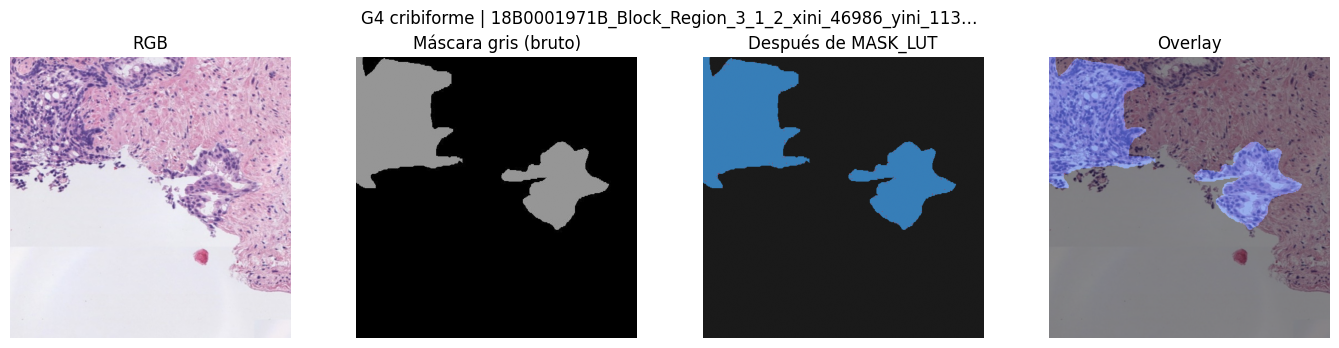

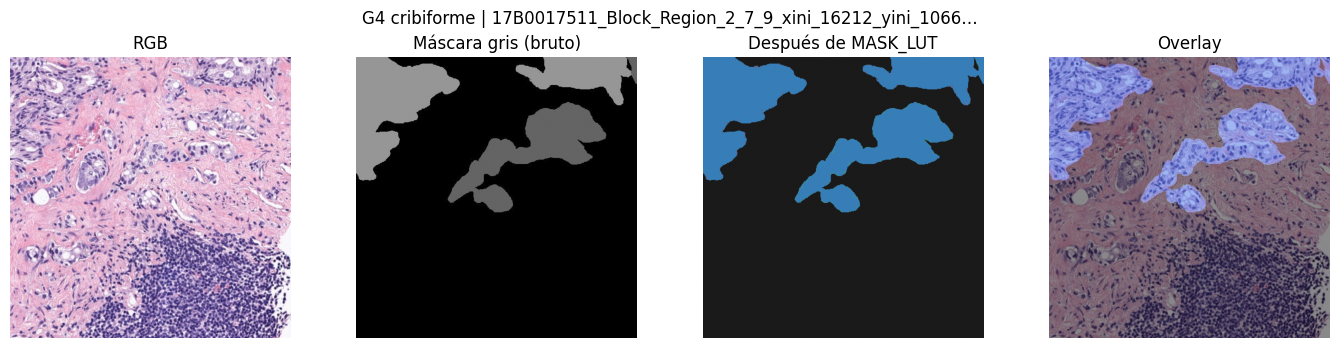

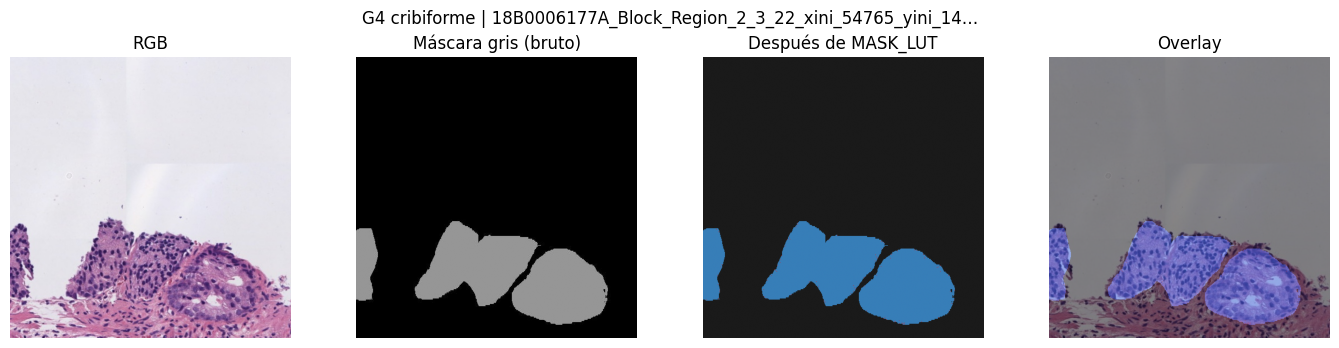

--- Ejemplos G4 + G4C=0 ---


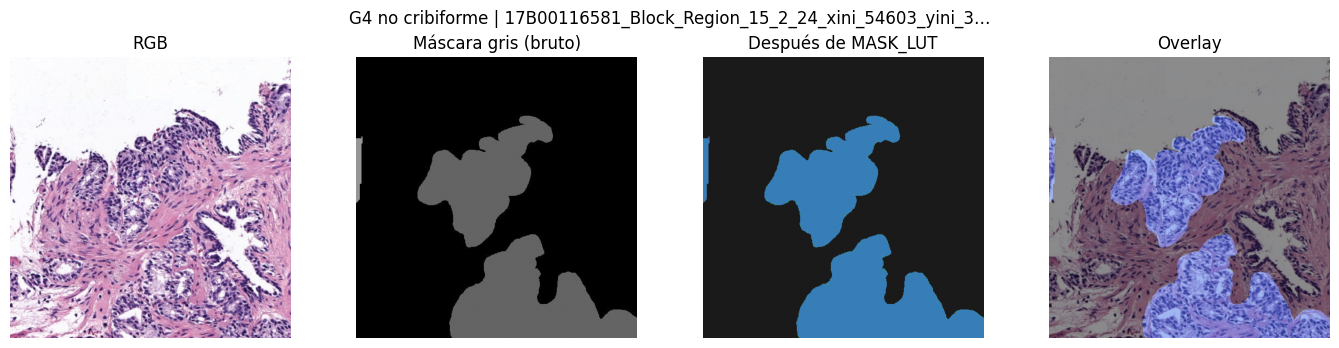

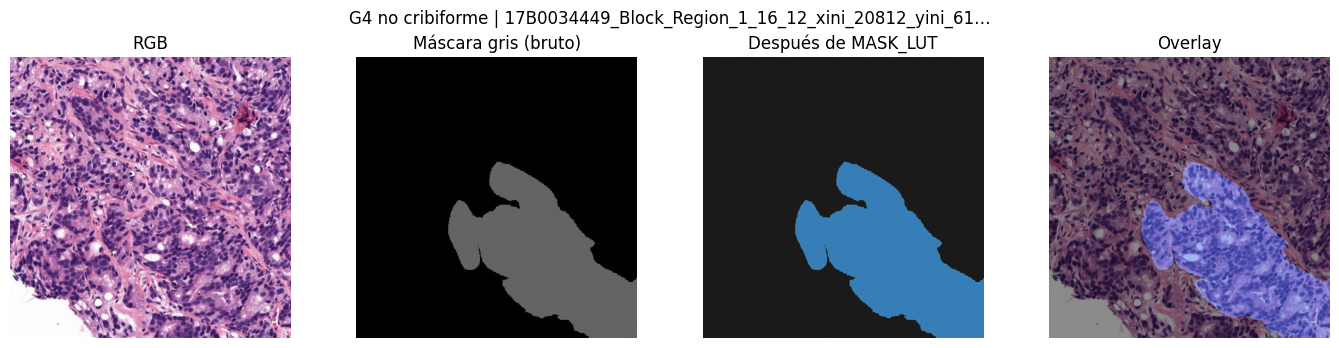

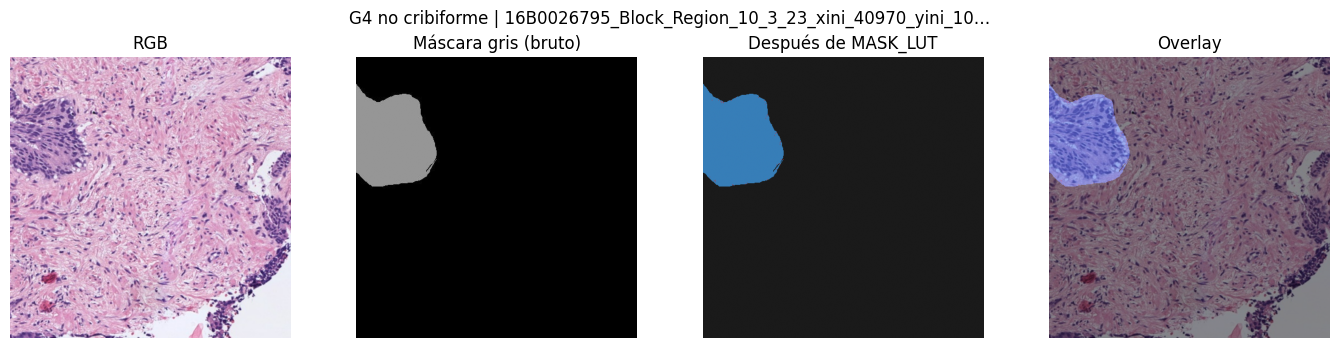

In [10]:
CMAP_LUT = ListedColormap(["#1a1a1a", "#4daf4a", "#377eb8", "#e41a1c"])  # NC, G3, G4, G5


def show_patch_row(name: str, title: str = ""):
    img = read_image_rgb(name)
    m = read_mask_gray(name)
    if img is None or m is None:
        print("Falta imagen o mask:", name)
        return
    mapped = MASK_LUT[m]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    axes[0].imshow(img)
    axes[0].set_title("RGB")
    axes[1].imshow(m, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Máscara gris (bruto)")
    axes[2].imshow(mapped, cmap=CMAP_LUT, vmin=0, vmax=3)
    axes[2].set_title("Después de MASK_LUT")
    ov = img.copy().astype(np.float32) / 255.0
    color = np.zeros((*mapped.shape, 3), dtype=np.float32)
    color[mapped == 1] = [0.2, 0.8, 0.2]
    color[mapped == 2] = [0.2, 0.4, 0.9]
    color[mapped == 3] = [0.95, 0.2, 0.2]
    ov = 0.55 * ov + 0.45 * color
    axes[3].imshow(np.clip(ov, 0, 1))
    axes[3].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(title or name[:60] + "…")
    plt.tight_layout()
    plt.show()


def sample_names(names: list[str], k: int = 3) -> list[str]:
    if not names:
        return []
    if len(names) <= k:
        return names
    return list(RNG.choice(names, size=k, replace=False))


print("--- Ejemplos G4 + G4C=1 ---")
for n in sample_names(names_g4_crib, 3):
    show_patch_row(n, title=f"G4 cribiforme | {n[:50]}…")

print("--- Ejemplos G4 + G4C=0 ---")
for n in sample_names(names_g4_plain, 3):
    show_patch_row(n, title=f"G4 no cribiforme | {n[:50]}…")

## Resumen para afinar la LUT

- Si los picos de gris **por clase** se solapan mucho entre `[43,85)`, `[85,GG5_min)` y `[GG5_min,255]` (con `GG5_min=DEFAULT_GG5_GRAY_MIN`, p. ej. 170), habrá confusión inherentemente; la LUT only puede **partir** el eje de gris en intervalos.
- **G4C** es subtipo clínico/anotación; en 4 clases ambos van a **GG4**. Si cribiforme y no cribiforme **no** se separan en intensidad dentro de `[85,GG5_min)`, no esperes una LUT de 4 clases que distinga G4C sin otra fuente de información.
- Próximo paso: probar umbrales alternativos only tras inspeccionar estos histogramas y el solape con **GG3** y **GG5**.